In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/friday_cleaned_ml.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547557 entries, 0 to 547556
Data columns (total 36 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Protocol                    547557 non-null  int64  
 1   Flow Duration               547557 non-null  int64  
 2   Total Fwd Packet            547557 non-null  int64  
 3   Total Length of Fwd Packet  547557 non-null  int64  
 4   Fwd Packet Length Min       547557 non-null  int64  
 5   Fwd Packet Length Mean      547557 non-null  float64
 6   Fwd Packet Length Std       547557 non-null  float64
 7   Bwd Packet Length Min       547557 non-null  int64  
 8   Flow Bytes/s                547557 non-null  float64
 9   Flow IAT Mean               547557 non-null  float64
 10  Flow IAT Std                547557 non-null  float64
 11  Flow IAT Min                547557 non-null  int64  
 12  Fwd PSH Flags               547557 non-null  int64  
 13  Fwd RST Flags 

In [4]:
df.describe()

,Protocol,Flow Duration,Total Fwd Packet,Total Length of Fwd Packet,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Min,Flow Bytes/s,Flow IAT Mean,...,PSH Flag Count,Down/Up Ratio,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Max,Idle Mean,Total TCP Flow Time,is_attack
count,547557.000000,5.475570e+05,547557.000000,547557.000000,547557.000000,547557.000000,547557.000000,547557.00000,5.475570e+05,5.475570e+05,...,547557.000000,547557.000000,547557.000000,547557.000000,547557.000000,547557.000000,5.475570e+05,5.475570e+05,5.475570e+05,547557.000000
mean,9.785144,9.252255e+06,8.726116,374.740299,15.274008,33.847723,37.066981,39.10346,3.371764e+05,6.228118e+05,...,2.208398,0.913226,9199.048046,580.539109,1.585382,20.087048,2.023936e+05,3.610678e+06,1.561664e+07,0.473034
std,5.233530,2.609339e+07,648.644128,3088.263160,31.526135,107.691395,169.462878,68.77839,3.324236e+06,2.884372e+06,...,17.416481,0.202965,12582.069688,3886.933699,5.164703,10.994899,1.071617e+06,1.149280e+07,1.899453e+08,0.499273
min,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000e+00,6.666667e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,6.000000,7.100000e+01,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000e+00,5.800000e+01,...,0.000000,0.857143,0.000000,0.000000,0.000000,8.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,3.114100e+04,2.000000,41.000000,0.000000,16.020000,0.000000,0.00000,1.226604e+03,1.140323e+04,...,0.000000,1.000000,1024.000000,0.000000,1.000000,20.000000,0.000000e+00,0.000000e+00,4.800000e+01,0.000000
75%,17.000000,5.032396e+06,8.000000,88.000000,35.000000,44.000000,7.071068,74.00000,6.368100e+03,3.612156e+05,...,2.000000,1.000000,8192.000000,229.000000,1.000000,24.000000,0.000000e+00,0.000000e+00,4.507917e+06,1.000000
max,17.000000,1.200000e+08,207963.000000,624776.000000,1472.000000,5775.500000,7018.511024,1454.00000,1.781765e+08,6.799952e+07,...,4869.000000,9.071429,65535.000000,65535.000000,855.000000,44.000000,1.100975e+08,1.199912e+08,2.676050e+10,1.000000


In [5]:
X = df.drop(["Label", "is_attack"], axis=1)
y = df["is_attack"]

In [6]:
X

,Protocol,Flow Duration,Total Fwd Packet,Total Length of Fwd Packet,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Min,Flow Bytes/s,Flow IAT Mean,...,RST Flag Count,PSH Flag Count,Down/Up Ratio,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Max,Idle Mean,Total TCP Flow Time
0,6,112740690,32,6448,0,201.500000,204.724205,72,6.741133e+01,2.398738e+06,...,0,32,0.500000,377,2079,15,32,380,16105402.14,112740690
1,6,112740560,32,6448,0,201.500000,204.724205,316,1.020396e+02,2.398735e+06,...,0,32,0.500000,955,2079,15,32,330,16105427.43,112740560
2,0,113757377,545,0,0,0.000000,0.000000,0,0.000000e+00,2.091128e+05,...,0,0,0.000000,0,0,0,0,18851791,12210358.40,0
3,17,91997219,388,37151,37,95.750000,55.785320,0,4.038274e+02,2.377189e+05,...,0,0,0.000000,0,0,387,8,24721964,13197637.00,0
4,17,66966070,6,288,48,48.000000,0.000000,48,8.601371e+00,6.087825e+06,...,0,0,1.000000,0,0,5,8,1968172,64974431.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547552,6,64,1,0,0,0.000000,0.000000,0,0.000000e+00,6.400000e+01,...,1,0,1.000000,1024,0,0,24,0,0.00,64
547553,6,76,1,0,0,0.000000,0.000000,0,0.000000e+00,7.600000e+01,...,1,0,1.000000,29200,0,0,40,0,0.00,76
547554,6,81,1,0,0,0.000000,0.000000,0,0.000000e+00,8.100000e+01,...,1,0,1.000000,1024,0,0,24,0,0.00,81
547555,17,297,2,68,34,34.000000,0.000000,139,1.164983e+06,9.900000e+01,...,0,0,1.000000,0,0,1,8,0,0.00,0


In [7]:
y

0         0
1         0
2         0
3         0
4         0
         ..
547552    1
547553    1
547554    1
547555    0
547556    0
Name: is_attack, Length: 547557, dtype: int64

In [8]:
X.dtypes.value_counts()

int64      23
float64    11
Name: count, dtype: int64

In [9]:
df["is_attack"].value_counts()

is_attack
0    288544
1    259013
Name: count, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (438045, 34), Test size: (109512, 34)


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pipelines = {
    "SGD (Baseline)": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SGDClassifier(random_state=42, max_iter=1000))
    ]),
    "CatBoost": Pipeline([
        ('model', CatBoostClassifier(iterations=1000, silent=True, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ('model', XGBClassifier(n_estimators=1000, random_state=42))
    ]),
    "LightGBM": Pipeline([
        ('model', LGBMClassifier(n_estimators=1000, random_state=42))
    ])
}

In [13]:
import time
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
results = []

# for name, pipe in pipelines.items():
#     start_time = time.time()
#     pipe.fit(X_train, y_train)
#     end_time = time.time()
#     duration = end_time - start_time 
    
#     y_pred = pipe.predict(X_test)
#     model = pipe.named_steps['model']
#     if "SGD" not in name:
#         feature_importances = model.feature_importances_
#         feat_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
#         feat_imp = feat_imp.sort_values(by='Importance', ascending=False)
    
#         print("Топ-10 признаков, на которых модель 'выезжает':")
#         print(feat_imp.head(10))
#         plt.figure(figsize=(10, 6))
#         sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
#         plt.title('Top 10 Features (Data Leakage Hunt)')
#         plt.show()
    
#     results.append({"Model": name,
#                     "F1-score": f1_score(y_test, y_pred),
#                     "Recall": recall_score(y_test, y_pred),
#                     "Precision": precision_score(y_test, y_pred),
#                     "Accuracy": accuracy_score(y_test, y_pred)})
#     print(classification_report(y_test, y_pred))
#     cmd = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
#     cmd.plot()
#     plt.show()

In [14]:
features_to_drop = ['Total Length of Fwd Packet', 'Flow IAT Min', 'Flow IAT Std', 'RST Flag Count']

X_train_clean = X_train.drop(columns=features_to_drop, errors='ignore')
X_test_clean = X_test.drop(columns=features_to_drop, errors='ignore')

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     57709
           1       0.99      1.00      0.99     51803

    accuracy                           1.00    109512
   macro avg       1.00      1.00      1.00    109512
weighted avg       1.00      1.00      1.00    109512



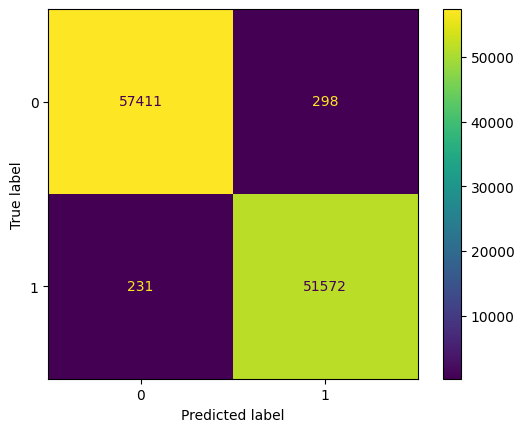

Топ-10 признаков, на которых модель 'выезжает':
                   Feature  Importance
4   Fwd Packet Length Mean   65.158404
24      Bwd Init Win Bytes    6.071954
18       Packet Length Std    5.784898
11           Bwd RST Flags    3.522743
20          SYN Flag Count    3.041668
15           Bwd Packets/s    2.546051
5    Fwd Packet Length Std    1.956385
23      FWD Init Win Bytes    1.644951
8            Flow IAT Mean    1.432622
7             Flow Bytes/s    1.057984


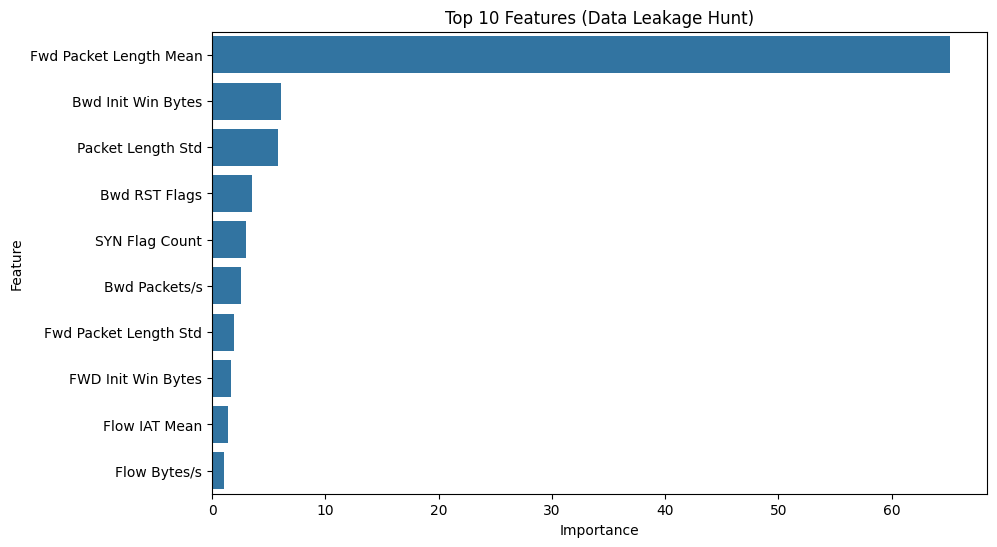

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     57709
           1       1.00      1.00      1.00     51803

    accuracy                           1.00    109512
   macro avg       1.00      1.00      1.00    109512
weighted avg       1.00      1.00      1.00    109512



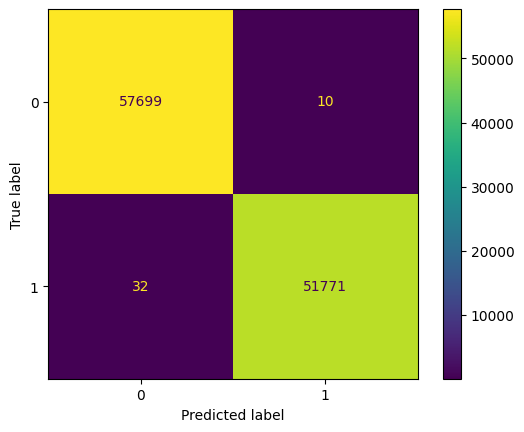

Топ-10 признаков, на которых модель 'выезжает':
                   Feature  Importance
4   Fwd Packet Length Mean    0.884610
10           Fwd RST Flags    0.033836
24      Bwd Init Win Bytes    0.027339
2         Total Fwd Packet    0.014837
20          SYN Flag Count    0.014782
5    Fwd Packet Length Std    0.008198
7             Flow Bytes/s    0.003950
29     Total TCP Flow Time    0.002611
17      Packet Length Mean    0.002070
18       Packet Length Std    0.001816


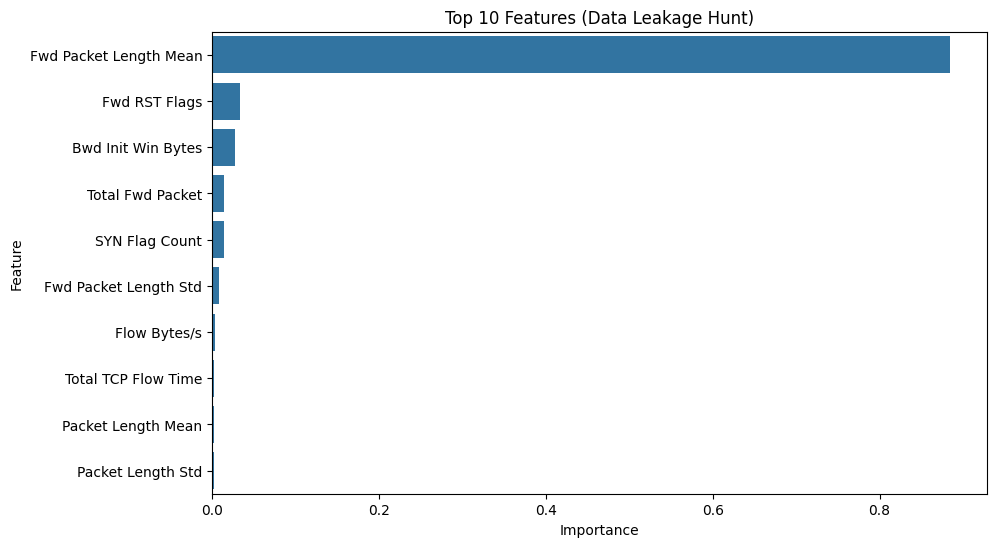

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     57709
           1       1.00      1.00      1.00     51803

    accuracy                           1.00    109512
   macro avg       1.00      1.00      1.00    109512
weighted avg       1.00      1.00      1.00    109512



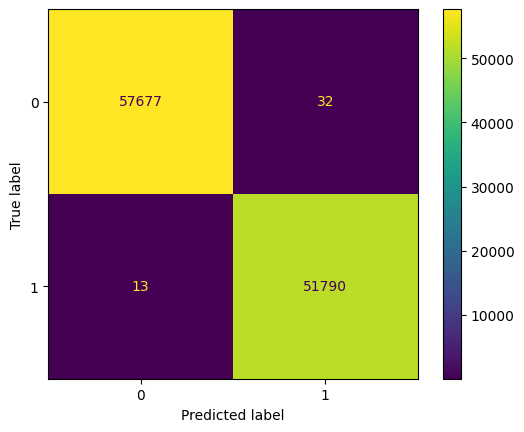

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1036, in __init__


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 207210, number of negative: 230835
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5426
[LightGBM] [Info] Number of data points in the train set: 438045, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473034 -> initscore=-0.107970
[LightGBM] [Info] Start training from score -0.107970
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

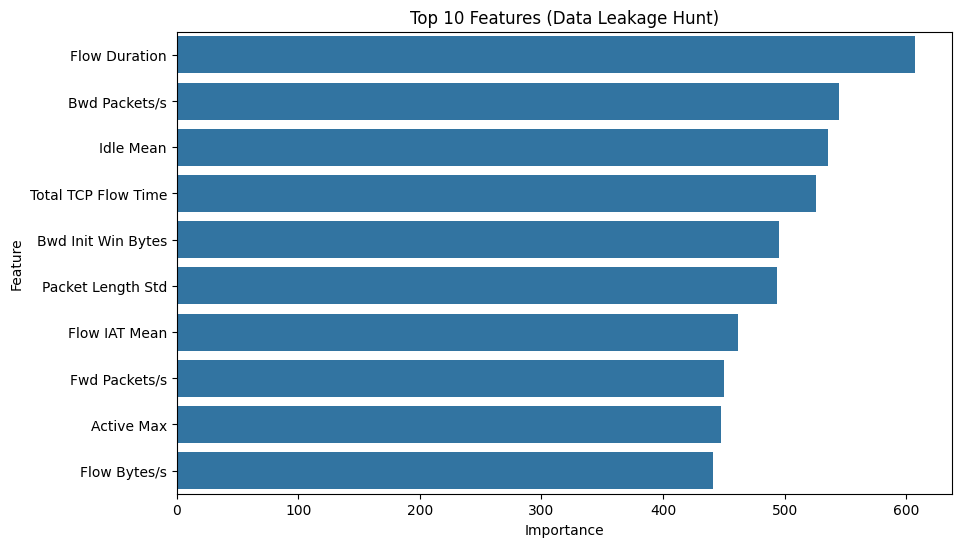

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     57709
           1       0.99      0.99      0.99     51803

    accuracy                           0.99    109512
   macro avg       0.99      0.99      0.99    109512
weighted avg       0.99      0.99      0.99    109512



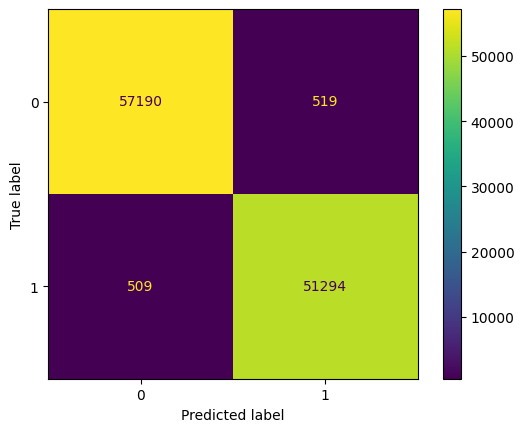

In [15]:
results = []

for name, pipe in pipelines.items():
    start_time = time.time()
    pipe.fit(X_train_clean, y_train)
    end_time = time.time()
    duration = end_time - start_time 
    
    y_pred = pipe.predict(X_test_clean)
    model = pipe.named_steps['model']
    if "SGD" not in name:
        feature_importances = model.feature_importances_
        feat_imp = pd.DataFrame({'Feature': X_train_clean.columns, 'Importance': feature_importances})
        feat_imp = feat_imp.sort_values(by='Importance', ascending=False)
        print("Топ-10 признаков, на которых модель 'выезжает':")
        print(feat_imp.head(10))
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
        plt.title('Top 10 Features (Data Leakage Hunt)')
        plt.show()
    
    results.append({"Model": name,
                    "F1-score": f1_score(y_test, y_pred),
                    "Recall": recall_score(y_test, y_pred),
                    "Precision": precision_score(y_test, y_pred),
                    "Accuracy": accuracy_score(y_test, y_pred)})
    print(classification_report(y_test, y_pred))
    cmd = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
    cmd.plot()
    plt.show()

Since dataset provides obvious hints for model to train on I cannot guarantee the future stability for this model. I need another dataset for this project. With that being said, this project meets its conclusion.